In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

import copy

from lina.utils import TikhonovInverse

from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from psd_utils import PSDUtils

from model import telescope
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Mon Jun  8 12:24:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             65W /  300W |    5486MiB /  81920MiB |     10%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [3]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 624.5
Image 02 SNR = 1012.7
Image 03 SNR = 575.5
Image 04 SNR = 1249.5
Image 05 SNR = 751.7
Image 06 SNR = 681.7
Image 07 SNR = 1129.7


## PLOT PSFS

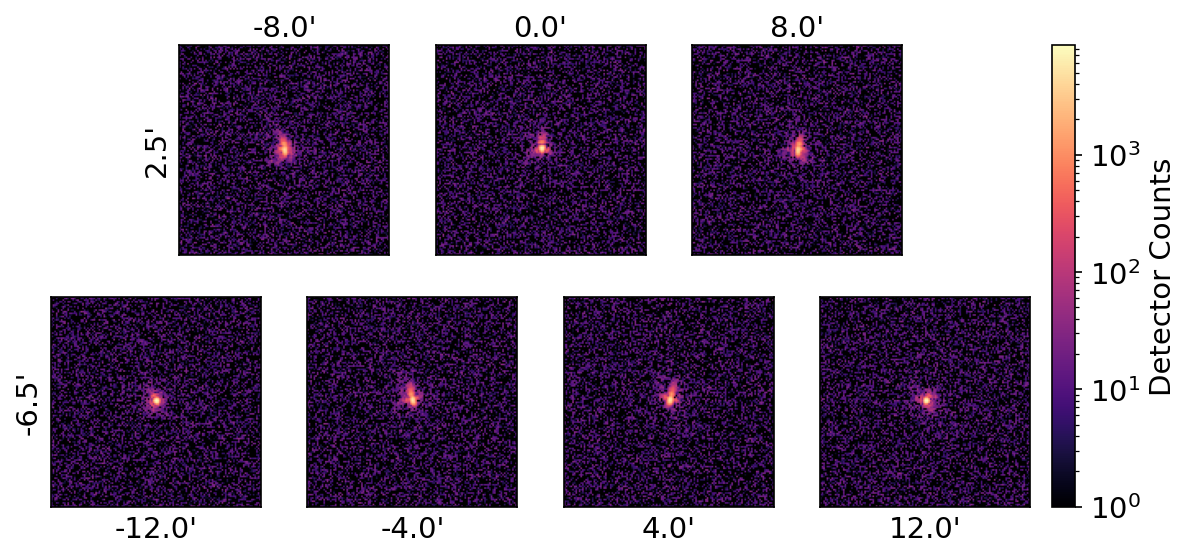

In [4]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## PLOT WFES

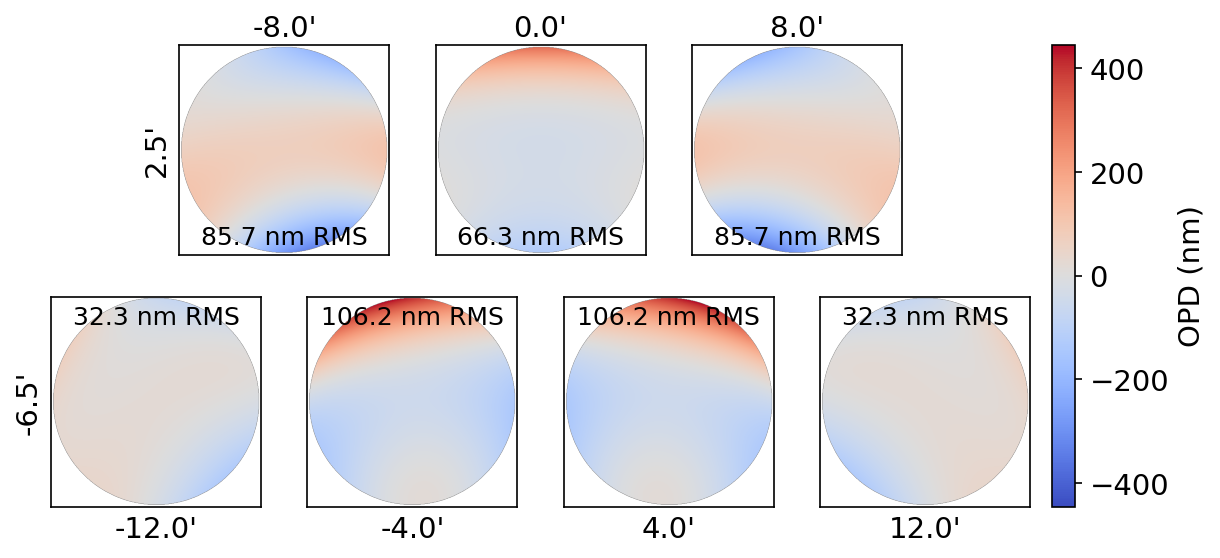

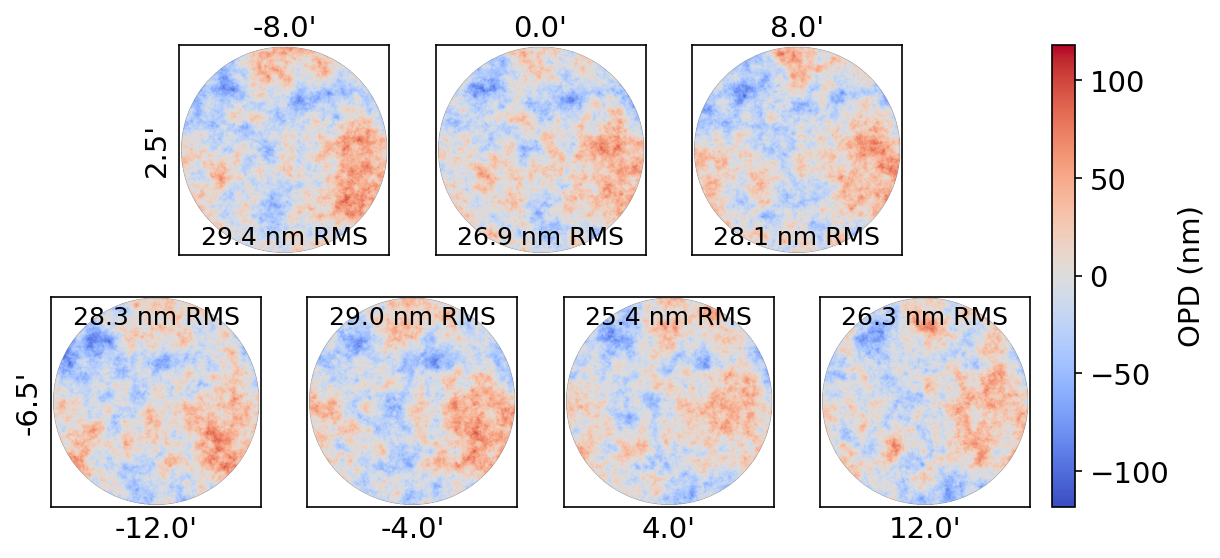

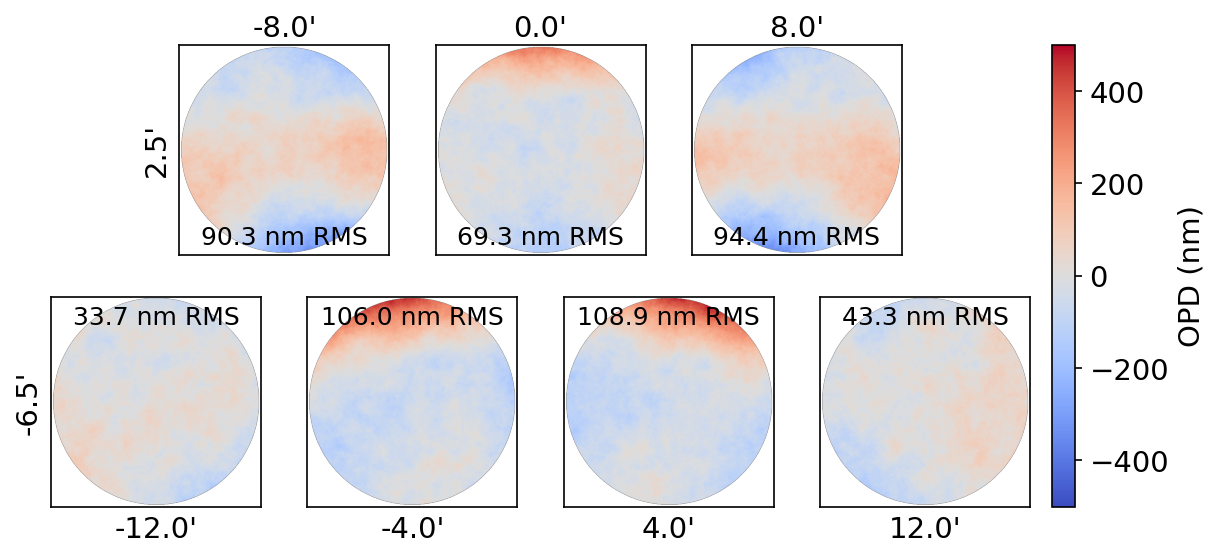

In [5]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_total = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_total, pupil=pupil, fields=fields)

## MISALIGNMENT GENERATOR FUNCTION

In [8]:
def generate_misalignment(range_decenter, range_tilt, rng):
    
    M1_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'z' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}

    M2_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'z' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    M3_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'z' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    M4_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'z' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    return {'M1' : M1_motion,
            'M2' : M2_motion,
            'M3' : M3_motion,
            'M4' : M4_motion}

## GENERATE AND SAVE CASES

In [9]:
n = 100
misalignments = []

range_decenter = 100e-6 # 100 um
range_tilt = 4.84814e-5 # 10 arcsec (converted to rad for raytrace model)

# set seed for repeatability WYSI
rng_np = _np.random.default_rng(seed=727)

for _ in range(n):
    misalignments.append(generate_misalignment(range_decenter=range_decenter, range_tilt=range_tilt, rng=rng_np))

utils.save_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_100um_tilt_10as.pkl', data=misalignments)

Saved data to:  /home/derbyk/src/ffpr/data/misalignments_cases_100_dec_100um_tilt_10as.pkl


In [10]:
n = 100
misalignments = []

range_decenter = 100e-6 / 2 # 50 um
range_tilt = 4.84814e-5 / 2 # 5 arcsec (converted to rad for raytrace model)

# set seed for repeatability WYSI
rng_np = _np.random.default_rng(seed=727)

for _ in range(n):
    misalignments.append(generate_misalignment(range_decenter=range_decenter, range_tilt=range_tilt, rng=rng_np))

utils.save_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_50um_tilt_5as.pkl', data=misalignments)

Saved data to:  /home/derbyk/src/ffpr/data/misalignments_cases_100_dec_50um_tilt_5as.pkl


In [11]:
n = 100
misalignments = []

range_decenter = 100e-6 / 5 # 20 um
range_tilt = 4.84814e-5 / 5 # 2 arcsec (converted to rad for raytrace model)

# set seed for repeatability WYSI
rng_np = _np.random.default_rng(seed=727)

for _ in range(n):
    misalignments.append(generate_misalignment(range_decenter=range_decenter, range_tilt=range_tilt, rng=rng_np))

utils.save_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_20um_tilt_2as.pkl', data=misalignments)

Saved data to:  /home/derbyk/src/ffpr/data/misalignments_cases_100_dec_20um_tilt_2as.pkl


## VISUALIZE

In [6]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_50um_tilt_5as.pkl')

In [9]:
median_rms = []
median_pv = []

for m in misalignments:

    sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

    opds_fields = copy.deepcopy(sys.opds_field)
    opds_optics = copy.deepcopy(sys.opds_optics)
    opds_total = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

    rms_per_field = []
    pv_per_field = []

    for opd in opds_total:
        opd -= np.mean(opd[pupil])
        rms_per_field.append(np.sqrt(np.mean(opd[pupil] ** 2)))
        pv_per_field.append(np.max(opd[pupil]) - np.min(opd[pupil]))

    median_rms.append(float(np.median(np.array(rms_per_field))))
    median_pv.append(float(np.median(np.array(pv_per_field))))

Text(0, 0.5, 'Count')

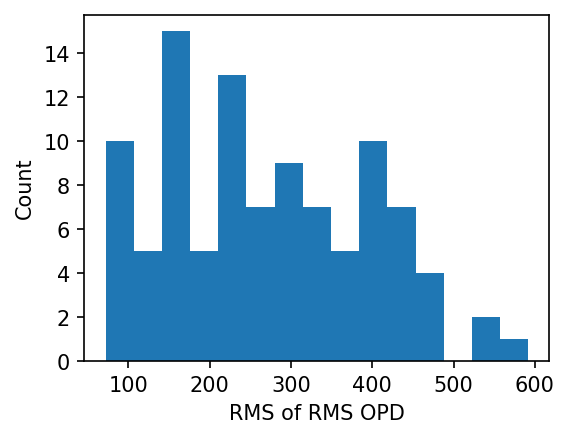

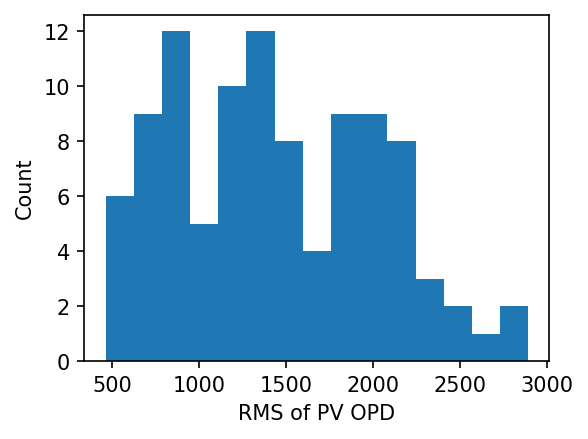

In [10]:
plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(median_rms).get(), bins=15)
plt.xlabel('RMS of RMS OPD')
plt.ylabel('Count')

plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(median_pv).get(), bins=15)
plt.xlabel('RMS of PV OPD')
plt.ylabel('Count')